In [4]:
from __future__ import annotations

import random
from pathlib import Path
from tqdm.auto import tqdm
import cv2
import numpy as np
import random
from torch.utils.data import Subset
from acr_tone import finish
from dataset_sim import *
from torch.utils.data import (ConcatDataset, DataLoader, Dataset, Subset,
                              WeightedRandomSampler)
cv2.setNumThreads(0)

/home/damien/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import os, subprocess

def pick_free_gpu(min_free_mb=8000):
    """Index du GPU le plus libre, d'après nvidia-smi (voit aussi les autres users)."""
    out = subprocess.run(
        ["nvidia-smi", "--query-gpu=index,memory.used,memory.total",
         "--format=csv,noheader,nounits"],
        capture_output=True, text=True, check=True).stdout.strip().splitlines()
    free = sorted(((int(tot) - int(used), int(i))
                   for i, used, tot in (l.split(", ") for l in out)), reverse=True)
    mb, idx = free[0]
    if mb < min_free_mb:
        raise RuntimeError(f"aucun GPU avec {min_free_mb} MiB libres (max dispo : {mb})")
    return idx, mb

idx, mb = pick_free_gpu()
os.environ["CUDA_VISIBLE_DEVICES"] = str(idx)
print(f"GPU {idx} choisi, {mb} MiB libres")

GPU 4 choisi, 24572 MiB libres


In [6]:
DEVICE = "cuda"

In [7]:
def real(samples):
    return PairedImageDataset(samples, size=384, train=False, jpeg=None, frac=(1.0,1.0))

In [8]:
def sim(path, matching_train=False):
    if matching_train:
        return SimulatedNpzDataset(path, finish, tone=True, ev_jitter=(-1.9,0.9),
                               jpeg=JpegAug(), seed=0, t_key="true_t")
    return SimulatedNpzDataset(path, finish, tone=True, ev_jitter=None,
                               jpeg=JpegAug(), seed=0, t_key="true_t")

In [9]:
datasets = {
    "nature":  real(build_by_stem(OTHERS / "nature_dataset", "natural_I", "natural_T")),
    "real89":  real(build_by_stem(OTHERS / "real89/real89")),
    "voc":     real(build_voc()),
    "sim150k": sim("/home/damien/data_fivek_dng/dataset_final_test1"),
    "sim10k":  sim("/home/damien/data_fivek_dng/dataset_soomin_final_biased"),
}

In [10]:
for name in datasets.keys():
    print(len(datasets[name]), name)

200 nature
89 real89
7643 voc
150000 sim150k
10000 sim10k


In [11]:
for name, samples in eval_specs().items():
    datasets[f"eval_{name}"] = real(samples)

In [12]:
idx = sorted(random.Random(0).sample(range(len(datasets["sim150k"])), 5_000))
idx2 = sorted(random.Random(0).sample(range(len(datasets["sim10k"])), 5_000))
datasets["sim50k"] = Subset(datasets["sim150k"], idx)
datasets["sim10k"] = Subset(datasets["sim10k"], idx2)
del datasets["sim150k"]

In [13]:
def run(ds, fn, batch_size=10):
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                        num_workers=16, pin_memory=True)
    out = {}
    with torch.no_grad():
        for b in tqdm(loader):
            M = b["mixed"].cuda(non_blocking=True)
            T = b["transmission"].cuda(non_blocking=True)
            for k, v in fn(M, T).items():
                out.setdefault(k, []).append(v.cpu())
    return {k: torch.cat(v) for k, v in out.items()}

In [15]:
from diffusers import AutoencoderKL

vae = AutoencoderKL.from_pretrained(
    "black-forest-labs/FLUX.2-klein-4B",
    subfolder="vae",
    torch_dtype=torch.bfloat16 #careful
).to(DEVICE)

/home/damien/.local/lib/python3.10/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Some weights of the model checkpoint at black-forest-labs/FLUX.2-klein-4B were not used when initializing AutoencoderKL: 
 ['bn.running_var, bn.num_batches_tracked, bn.running_mean']


In [36]:
LUMA = torch.tensor([0.2126, 0.7152, 0.0722], device="cuda").view(1, 3, 1, 1)

def stats(M, T):                        
    Ym = (M * LUMA).sum(1)    
    Tm = (T * LUMA).sum(1).flatten(1).mean(1)          
    mx, mn = M.amax(1), M.amin(1)       
    chroma = torch.where(mx > 0.05, (mx - mn) / mx.clamp_min(1e-6), 0.0)
    z = vae.encode((M * 2 - 1).to(torch.bfloat16)).latent_dist.mean.float()  # (B, 32, 48, 48)
    z = z.flatten(2) # (B, 32, 1, 1)
    return {
        "Y mean":    Ym.flatten(1).mean(1), # exposure
        "Y std"  : Ym.flatten(1).std(1),
        "chroma":     chroma.flatten(1).mean(1),
        "frac burned pixels": (mx >= 254/255).float().flatten(1).mean(1),
        "frac black": (mx <= 2/255).float().flatten(1).mean(1),
        "frac T>M" : ((T > M + 1/255).float().flatten(1).mean(1)),
        "mean M" : M.flatten(1).mean(1),
        "vae" : torch.cat([z.mean(2), z.std(2)], 1),
        "Y_t" : Tm,
    }

In [37]:
results = {name: run(ds, stats) for name, ds in datasets.items()}

100%|██████████| 500/500 [01:20<00:00,  6.20it/s]


In [ ]:
results.keys()

dict_keys(['nature', 'real89', 'voc', 'sim10k', 'eval_postcard', 'eval_solid', 'eval_wild', 'eval_nature20', 'eval_real20', 'sim50k'])

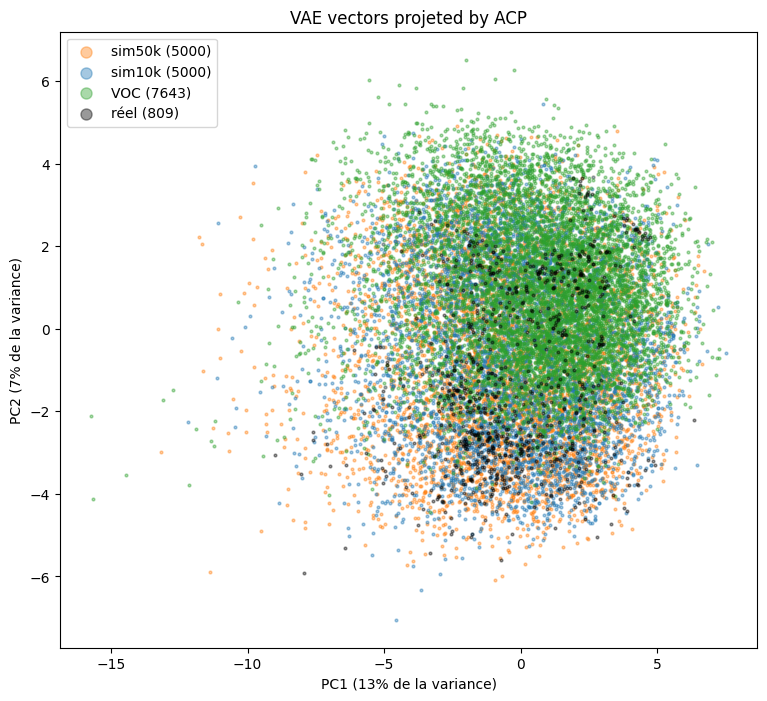

In [38]:
import matplotlib.pyplot as plt

def group(name):
    if name == "voc":
        return "VOC"
    if name.startswith("sim"):
        return name                    # sim10k, sim50k
    return "réel"                      # nature, real89, eval_*

colors = {"réel": "black", "VOC": "tab:green", "sim10k": "tab:blue", "sim50k": "tab:orange"}

# rassembler les vecteurs VAE par type
G = {}
for name, r in results.items():
    G.setdefault(group(name), []).append(r["vae"])
G = {g: torch.cat(v) for g, v in G.items()}

# ACP sur tous les points
X = torch.cat(list(G.values()))
mu, sd = X.mean(0), X.std(0)
_, s, Vh = torch.linalg.svd((X - mu) / sd, full_matrices=False)
W = Vh[:2].T                                       # (64, 2)
var = (s**2 / (s**2).sum())[:2].tolist()

fig, ax = plt.subplots(figsize=(9, 8))
for g in ["sim50k", "sim10k", "VOC", "réel"]:      # réel dessiné en dernier pour rester visible
    p = ((G[g] - mu) / sd) @ W
    ax.scatter(p[:, 0], p[:, 1], s=4, alpha=0.4, color=colors[g], label=f"{g} ({len(p)})")
ax.set_xlabel(f"PC1 ({var[0]:.0%} de la variance)")
ax.set_ylabel(f"PC2 ({var[1]:.0%} de la variance)")
ax.set_title("VAE vectors projeted by ACP")
ax.legend(markerscale=4)
plt.show()


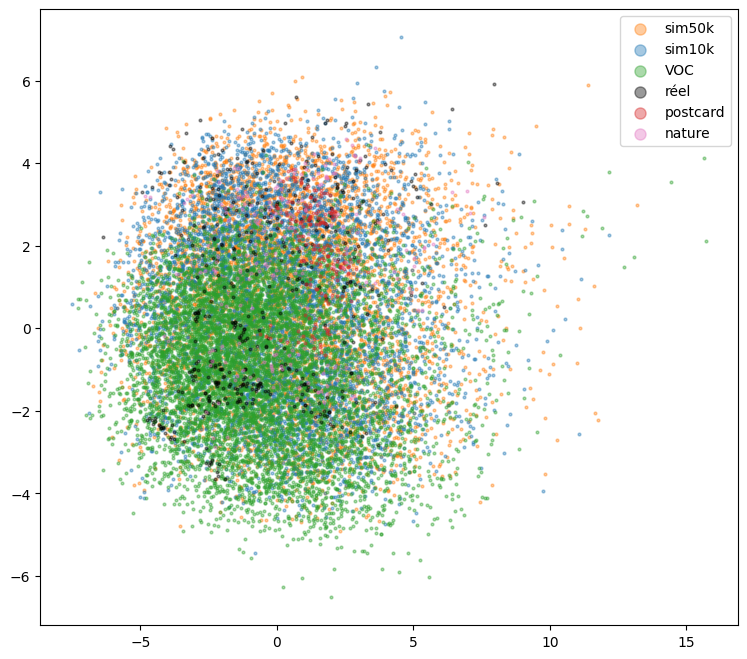

In [57]:
import matplotlib.pyplot as plt

groupes = {
    "réel":   [ "real89", "eval_solid", "eval_wild", "eval_nature20", "eval_real20"],
    "VOC":    ["voc"],
    "sim10k": ["sim10k"],
    "sim50k": ["sim50k"],
    "postcard" : ["eval_postcard"],
    "nature": ["nature"]
}
couleurs = {"sim50k": "tab:orange", "sim10k": "tab:blue", "VOC": "tab:green", "réel": "black", "postcard": "tab:red", "nature":"tab:pink"}

# un tableau (N, 64) par groupe
F = {g: torch.cat([results[n]["vae"] for n in noms]) for g, noms in groupes.items()}

# ACP : les 2 directions où les données varient le plus
X = torch.cat(list(F.values()))
mu, sd = X.mean(0), X.std(0)
_, _, Vh = torch.linalg.svd((X - mu) / sd, full_matrices=False)

plt.figure(figsize=(9, 8))
for g in ["sim50k", "sim10k", "VOC", "réel", "postcard","nature"]:      # réel en dernier pour qu'il reste visible
    p = ((F[g] - mu) / sd) @ Vh[:2].T               # (N, 2)
    plt.scatter(p[:, 0], p[:, 1], s=4, alpha=0.4, color=couleurs[g], label=g)
plt.legend(markerscale=4)
plt.show()


In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import StratifiedKFold

def separabilite(A, B):
    X = torch.cat([A, B]).numpy()
    y = np.r_[np.zeros(len(A)), np.ones(len(B))]
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced"))
    cv = StratifiedKFold(5, shuffle=True, random_state=0)
    s = cross_val_score(clf, X, y, cv=cv, scoring="balanced_accuracy")
    return s.mean(), s.std()

for g in ["VOC", "sim10k", "sim50k"]:
    m, e = separabilite(F[g], F["réel"])
    print(f"{g:7s} vs réel : {m:.2f} ± {e:.2f}")



VOC     vs réel : 0.98 ± 0.01
sim10k  vs réel : 0.94 ± 0.02
sim50k  vs réel : 0.94 ± 0.01


In [53]:
for n in groupes["réel"]:
    scores = [separabilite(F[g], results[n]["vae"])[0] for g in ["VOC", "sim10k", "sim50k"]]
    print(f"{n:15s}", "  ".join(f"{s:.2f}" for s in scores))

nature          1.00  0.98  0.99
real89          0.98  0.88  0.89
eval_solid      1.00  1.00  1.00
eval_wild       0.99  0.99  0.98
eval_nature20   0.92  0.85  0.90
eval_real20     0.90  0.90  0.80


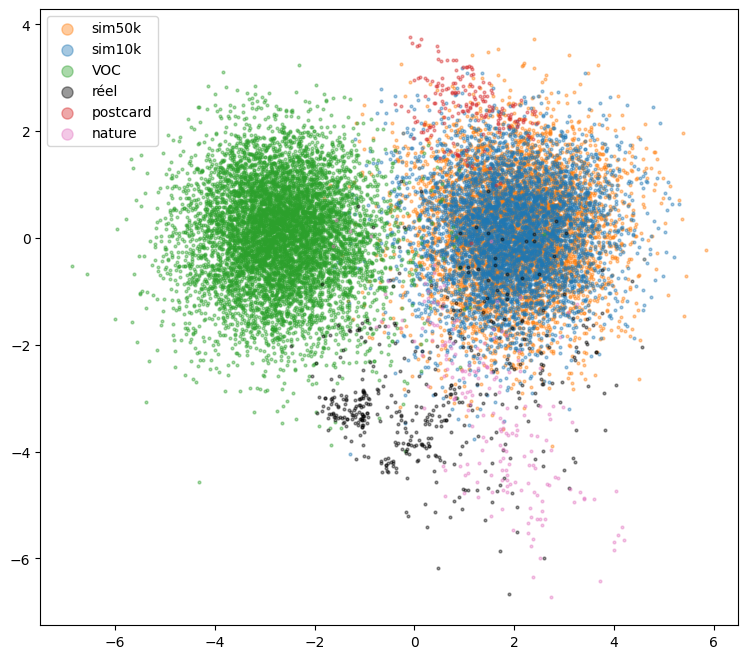

In [58]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X = torch.cat(list(F.values())).numpy()
y = np.concatenate([[g] * len(F[g]) for g in F])
P = LinearDiscriminantAnalysis(n_components=2).fit_transform(X, y)

plt.figure(figsize=(9, 8))
for g in ["sim50k", "sim10k", "VOC", "réel", "postcard", "nature"]:
    plt.scatter(P[y == g, 0], P[y == g, 1], s=4, alpha=0.4, color=couleurs[g], label=g)
plt.legend(markerscale=4)
plt.show()

In [24]:
cles = [k for k in results["voc"] if not k.startswith("vae")]   # toutes les stats sauf le VAE
noms = ["VOC", "sim10k", "sim50k"]

# un tableau (N, nb_stats) par groupe
S = {g: torch.cat([torch.stack([results[n][k] for k in cles], 1) for n in ds])
     for g, ds in groupes.items()}

# 1. score global avec toutes les stats
for g in noms:
    m, e = separabilite(S[g], S["réel"])
    print(f"{g:7s} vs réel : {m:.2f} ± {e:.2f}")

# 2. score avec une seule stat à la fois : laquelle trahit le plus ?
print(f"\n{'stat':20s}" + "".join(f"{g:>9s}" for g in noms))
for i, k in enumerate(cles):
    scores = [separabilite(S[g][:, [i]], S["réel"][:, [i]])[0] for g in noms]
    print(f"{k:20s}" + "".join(f"{s:9.2f}" for s in scores))

# 3. moyenne de chaque stat : dans quel sens c'est décalé ?
print(f"\n{'stat':20s}" + "".join(f"{g:>9s}" for g in ["réel"] + noms))
for i, k in enumerate(cles):
    print(f"{k:20s}" + "".join(f"{float(S[g][:, i].mean()):9.3f}" for g in ["réel"] + noms))


VOC     vs réel : 0.99 ± 0.00
sim10k  vs réel : 0.63 ± 0.01
sim50k  vs réel : 0.65 ± 0.01

stat                      VOC   sim10k   sim50k
Y mean                   0.68     0.59     0.60
Y std                    0.75     0.56     0.49
chroma                   0.60     0.60     0.61
frac burned pixels       0.91     0.52     0.51
frac black               0.58     0.53     0.53
frac T>M                 0.94     0.54     0.51
mean M                   0.69     0.60     0.61

stat                     réel      VOC   sim10k   sim50k
Y mean                  0.444    0.577    0.490    0.500
Y std                   0.180    0.253    0.197    0.179
chroma                  0.332    0.277    0.274    0.271
frac burned pixels      0.015    0.175    0.017    0.012
frac black              0.000    0.002    0.000    0.000
frac T>M                0.233    0.000    0.251    0.223
mean M                  0.436    0.580    0.486    0.496
